In [2]:
import numpy as np
import pandas as pd
import glob
from PIL import Image
import os

In [3]:
def load_png_slices(png_dir, axis=2):
    """Load PNG slices and stack into a 3D volume."""
    # Get sorted list of PNG files
    png_files = sorted(glob.glob(os.path.join(png_dir, "*.png")))
    if not png_files:
        raise ValueError(f"No PNG files found in {png_dir}")

    # Load first image to get dimensions
    first_img = Image.open(png_files[0]).convert("L")  # Grayscale
    width, height = first_img.size

    # Initialize 3D array
    volume = np.zeros((len(png_files), height, width), dtype=np.float32)

    # Load and stack slices
    for i, png_file in enumerate(png_files):
        img = Image.open(png_file).convert("L")
        volume[i] = np.array(img)

    # Reorient if needed (e.g., axial to [height, width, slices])
    if axis == 2:  # Axial
        volume = volume.transpose(1, 2, 0)  # Shape: (height, width, slices)

    return volume

load_png_slices('./ntua-parkinson-dataset/')

ValueError: No PNG files found in ./ntua-parkinson-dataset/

In [8]:
import SimpleITK as sitk
from skimage.transform import resize
from PIL import Image
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from preprocessing import helper
import napari

img_dir = "ntua-parkinson-dataset/pd-patients/Subject10/1.MRI"
df = pd.read_csv("labelled_patients.csv")

def visualise(img, title=None):
    viewer = napari.Viewer(title=title)
    viewer.add_image(sitk.GetArrayFromImage(img), name=title)
    napari.run()

def preprocess_volume(img_dir, target_shape=(64,128,128)):
    '''
    TODO: add comment
    '''
    img_files = helper.sort_img_files(img_dir)
    print(img_files)

    # stacking 2D images to build 3D volumes
    slices = []
    for img_path in img_files:
        # img_path = os.path.join(img_dir, img_path)
        img = Image.open(img_path).convert('L') # grayscale
        img_array = helper.normalise(img)
        img_array = resize(img_array, (target_shape[1], target_shape[2]), anti_aliasing=True)

        # check for blank slice
        if np.std(img_array) < 1e-8:
            print(f"Empty slice detected in {img_path}")
            return None # if empty, what should i do with the volume?

        slices.append(img_array)

    data = np.stack(slices, axis=0) # ensures (D, H, W); not (H, D, W); D = num_slices
    print(f"Stacked {len(slices)} in {img_dir}, shape={data.shape}")

    # resize depth
    if data.shape[0] != target_shape[0]:
        data = resize(data, target_shape, anti_aliasing=True)
        print(f"Resized depth to {target_shape[0]}, new shape={data.shape}")

    return data

for _, row in df.iterrows():
    modality = row['Type']
    data = preprocess_volume(row['FilePath'])
    print(row['FilePath'])

    # img = sitk.GetImageFromArray(data)
    # # plt.imshow(img)
    visualise(sitk.GetImageFromArray(data), title=row['FilePath']) 

    # visualise(img)
    break

['ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_001.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_002.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_003.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_004.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_005.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_006.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_007.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_008.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_009.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_010.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_011.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_012.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MRI/MPRAGE_SAG_013.png', 'ntua-parkinson-dataset/pd-patients/Subject46/1.MR

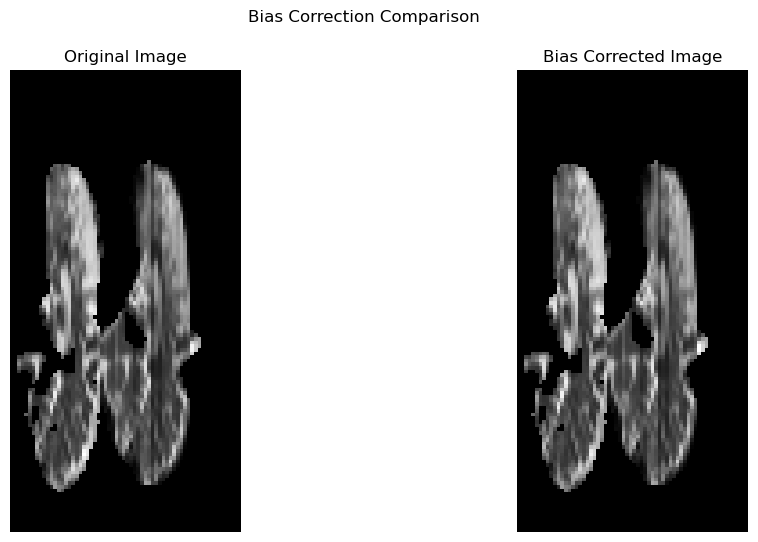

Saved corrected image to test_bias_correction/corrected_volume_04_label_0_stripped.nii.gz


In [5]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import os

def apply_n4_bias_correction(img_path):
    '''
    N4 Bias Field Correction to correct bias in MRI images
    '''
    img = sitk.ReadImage(img_path)
    img_float = sitk.Cast(img, sitk.sitkFloat32)  # transform to float
    mask = sitk.OtsuThreshold(img_float, 0, 1, 200)  # create mask
    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrected_img = corrector.Execute(img_float, mask)
    return img, corrected_img

def compare_images(original_img, corrected_img, title="Bias Correction Comparison"):
    '''
    compare original and bias-corrected images
    '''
    # SimpleITK -> numpy array
    original_array = sitk.GetArrayViewFromImage(original_img)
    corrected_array = sitk.GetArrayViewFromImage(corrected_img)

    # if the image is 3D, take a slice in the middle
    if original_array.ndim == 3:
        original_slice = original_array[original_array.shape[0]//2]
        corrected_slice = corrected_array[corrected_array.shape[0]//2]
    else:
        original_slice = original_array
        corrected_slice = corrected_array

    # plotting
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(original_slice, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(corrected_slice, cmap='gray')
    axes[1].set_title('Bias Corrected Image')
    
    axes[1].axis('off')

    fig.suptitle(title)
    plt.show()

def save_corrected_image(corrected_img, save_path):
    '''
    image saving
    '''
    sitk.WriteImage(corrected_img, save_path)
    print(f"Saved corrected image to {save_path}")

# main function
if __name__ == "__main__":
    img_path = "stripped-output/volume_04_label_0_stripped.nii.gz"  
    save_dir = "test_bias_correction"
    os.makedirs(save_dir, exist_ok=True)

    original_img, corrected_img = apply_n4_bias_correction(img_path)
    compare_images(original_img, corrected_img)
    
    # Save the corrected image
    filename = os.path.basename(img_path)
    save_corrected_image(corrected_img, os.path.join(save_dir, f"corrected_{filename}"))



>> 对 46 执行 N4 偏场校正 …


ValueError: No files matching *.nii.gz in stripped-output/Subject10